<header style="background-color: rgb(0, 62, 92); color: white; margin-top: 20px; padding:28px; ">
  <img src="../Images/Xlogo.png" alt="logo" width="115" style="float: left;">
  <p style=" text-align: center; font-size: 30px;">   
   <strong> APM_52448_EP - Deep Learning in Finance   </strong></p>
    <p style=" text-align: center; font-size: 30px;"> 
    <strong> Tutorial 1: Stock Price Forecasting (Deep Learning Refresher) </strong></p>
  <p style=" text-align: left; font-size: 20px;"> Olivier Féron </p>
</header>

**Goal.** Build an end-to-end, *time-aware* forecasting pipeline on daily equity data to experience the challenges of financial prediction and to align on deep learning vocabulary best practices.

**What you'll practice**
- Data retrieval & cleaning
- Proper *time-split* (train / validation / test) and preprocessing
- Baselines (neutral, persistence, linear regression)
- Neural nets (MLP)
- Regularization & early stopping
- Metrics: RMSE/MAE and directional accuracy

> **Important:** Financial series are noisy and difficult to predict. The *lesson* is as important as the numbers you get.


## 0. Setup

- Create/activate your Python environment (conda/venv).

In [1]:
import os, random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Fixing all random starts for reproducibility
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available()) # Check if GPU card is available


Torch version: 2.7.1+cpu
CUDA available: False


## 1. Data loading, and some basic analysis

In this notebook, data are already downloaded on csv file. But you can also download from yahoo finance by using "yahooquery" package.

csv files have name "ticker.csv" with ticker similar to the one needed to download from yahoo finance: (e.g., `AAPL` for Apple, `AI.PA` for Air Liquidie, `MC.PA` for LVMH).

<span style="color: blue;">**1.1** Download ~10 years of data (from 2014/01/01 to today), keep at least columns `Close` and `Volume`.</span>


In [2]:
START = "2014-01-01"
END   = None

df = pd.read_csv("../Data/AAPL.csv", parse_dates=["date"], index_col="date")
df = df[START:END]

df = df.dropna().copy().sort_index()

### 1.1 Basic Sanity Check

Before going further, make sure that the dataset has been correctly loaded.

<span style="color: blue;">**1.2** Display **some basic information** about the `df` Dataframe: </span>
- <span style="color: blue;">**Number of rows and columns**</span>
- <span style="color: blue;">**Head** and **Tail** of the Dataframe (first and lst few rows)</span>
- <span style="color: blue;">**Number of missing values (NaN)** in the Dataset </span>



In [5]:
print("Shape:", df.shape)
print(df.head())
print(df.tail())
print("NaNs per column:\n", df.isna().sum())

Shape: (2970, 12)
           symbol       open       high        low      close     volume  \
date                                                                       
2014-01-03   AAPL  19.745001  19.775000  19.301071  19.320715  392467600   
2014-01-06   AAPL  19.194643  19.528570  19.057142  19.426071  412610800   
2014-01-07   AAPL  19.440001  19.498571  19.211430  19.287144  317209200   
2014-01-08   AAPL  19.243214  19.484285  19.238930  19.409286  258529600   
2014-01-09   AAPL  19.528570  19.530714  19.119642  19.161428  279148800   

             adjclose  dividends  splits  log_close       ret    target  
date                                                                     
2014-01-03  16.796110        0.0     0.0   2.961178 -0.022211  0.005438  
2014-01-06  16.887690        0.0     0.0   2.966616  0.005438 -0.007177  
2014-01-07  16.766924        0.0     0.0   2.959439 -0.007177  0.006313  
2014-01-08  16.873098        0.0     0.0   2.965752  0.006313 -0.012852  
2014-

### 1.2 Basic Analysis

The first (and simplest) analysis when we have time series is to plot the data

<span style="color: blue;">**1.3** Plot the **close** price as a time series, and its histogram </span>

When working with financial time series, we almost always prefer to manipulate returns rather than raw prices, because returns have mathematical and statistical properties that make them far more suitable for modeling, comparison, and risk analysis. In particular, returns are more likely to be "stationary" than prices. 

<span style="color: blue;">**1.4** Compute the log returns $y_t = \log(P_t) - \log(P_{t-1})$ </span>

<span style="color: blue;">**1.5** Plot the resulting log returns as a time series, and its histogram </span>

<span style="color: blue;">**1.6** Compare the histogram with the Gaussian probability density function of same mean and std </span>

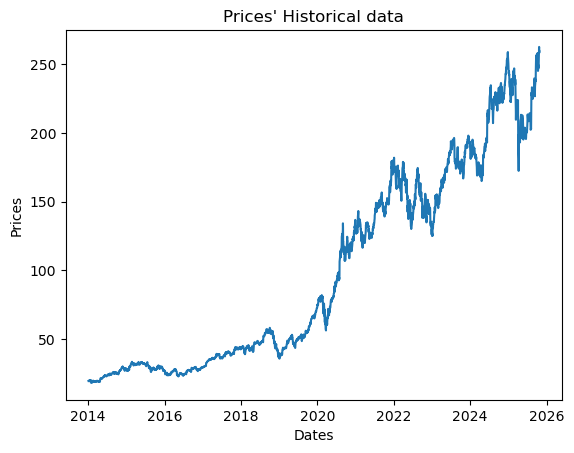

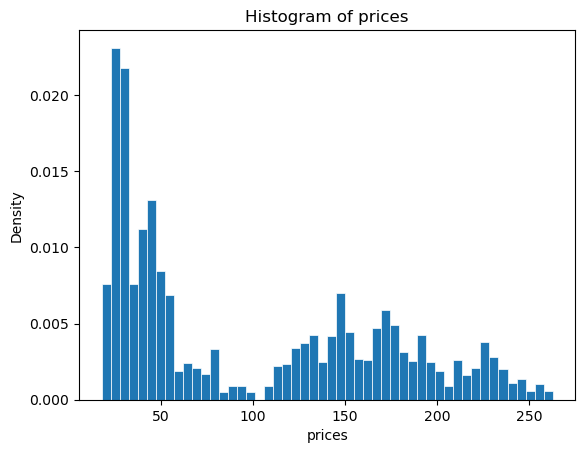

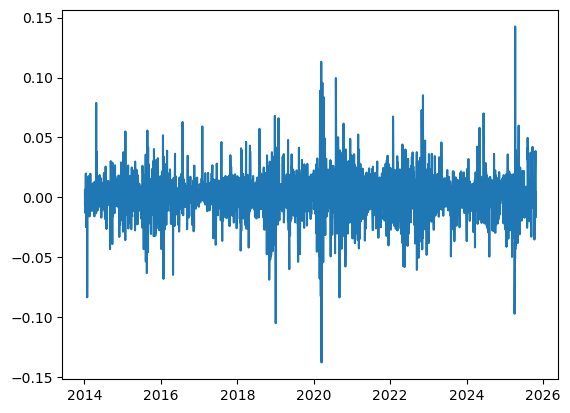

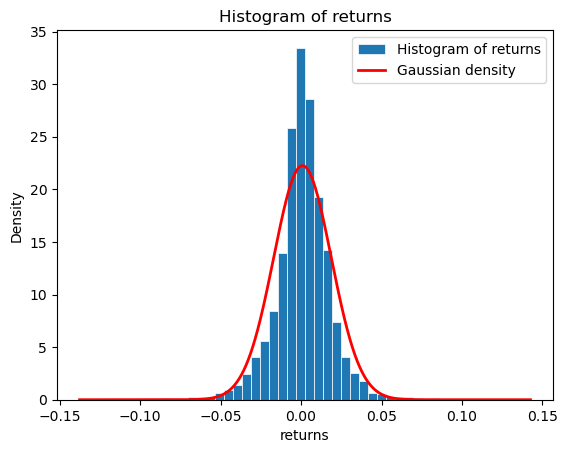

In [ ]:
plt.figure()
plt.plot(df["close"])
plt.title("Prices' Historical data")
plt.xlabel("Dates")
plt.ylabel("Prices")
plt.show()

plt.figure()
plt.hist(df["close"], bins=50, edgecolor="white", linewidth=0.5, density=True)
plt.title("Histogram of prices")
plt.xlabel("prices")
plt.ylabel("Density")
plt.show()

# Compute log-returns (on the closing price)
df["log_close"] = np.log(df["close"])
df["ret"] = df["log_close"].diff()

plt.figure()
plt.plot(df["ret"])
plt.show()



r = df["ret"].dropna().values
mu, sigma = r.mean(), r.std(ddof=1)  # type: ignore # usual estimators of mean and std


# Grid for plotting density
x = np.linspace(r.min(), r.max(), 1000)  # type: ignore
# Gaussian PDF (without scipy)
pdf = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)

plt.figure()
plt.hist(df["ret"], bins=50, edgecolor="white", linewidth=0.5, density=True, label="Histogram of returns")
plt.plot(x, pdf, color='red', lw=2, label="Gaussian density")
plt.title("Histogram of returns")
plt.xlabel("returns")
plt.ylabel("Density")
plt.legend()
plt.show()

## 2. Targets & features: Data preparation

We want to predict the **next-day log-return**, based on the observation of its historical realization (asssuming stationarity...).

The first objective is to create an appropriate Dataframe ready to use prediction tools. We then define the **target** $y_t$ as the element we want to predict, and the **features** $x_t$ as the explanotory variables used to predict $y_{t+1}$. We then must create a Dataframe where, on each line, there will be the features $x_t$ used and the realized target $y_{t+1}$: 
Ex. of Dataframe (one row):
| $x^1_t$ | $x^2_t$ |$\dots$ | $x^k_t$ | $y_{t+1}$ |

- Target $y_t = \log(P_t) - \log(P_{t-1})$, shifted so that **features at time t** predict **return at t+1**.
- Features: a rolling window of last $k$ log-returns (and optionally simple indicators): $x^i_t = y_{t-i+1}$.

<span style="color: blue;">**2.1** Create the column "target" corresponding, at time $t$, to $y_{t+1}. </span>

**Pay attention on time and line consistency**: here we want to build a dataframe such that on each line, we have the features and the target we want to predict.

In [7]:
# Shift target so that features at t predict ret at t+1
df["target"] = df["ret"].shift(-1)

# Drop initial NaNs
df = df.dropna().copy()
df[["close","ret","target"]].head()

,close,ret,target
date,,,
2014-01-06,19.426071,0.005438,-0.007177
2014-01-07,19.287144,-0.007177,0.006313
2014-01-08,19.409286,0.006313,-0.012852
2014-01-09,19.161428,-0.012852,-0.006695
2014-01-10,19.033571,-0.006695,0.005221


### 2.1 Windowed features

<span style="color: blue;">**2.2** Implement the function `make_window_features` that builds a matrix with the last `k` returns as features: `[ret_{t-k+1}, ..., ret_t]`. </span>

<span style="color: blue;">**2.3** Build the matrix `X` with the last `k=20` last returns as features: `[ret_{t-k+1}, ..., ret_t]`. </span>

<span style="color: blue;">**2.4** Print the first 2 lines of X. </span>


In [8]:
def make_window_features(returns: np.ndarray, k: int) -> np.ndarray:
    X = []
    for i in range(k-1, len(returns)):
        X.append(returns[i-k+1:i+1])
    return np.asarray(X)

K = 20
ret = df["ret"].to_numpy()
X = make_window_features(ret, K)
y = df["target"].to_numpy()[K-1:]
X.shape, y.shape

print(X[:2])

[[ 0.0054382  -0.00717729  0.00631289 -0.01285231 -0.006695    0.0052215
   0.01970271  0.01987829 -0.00559546 -0.02480677  0.01541689  0.00443404
   0.00843194 -0.01834477  0.0080797  -0.08330252 -0.01141742 -0.00193899
   0.00163936  0.00185606]
 [-0.00717729  0.00631289 -0.01285231 -0.006695    0.0052215   0.01970271
   0.01987829 -0.00559546 -0.02480677  0.01541689  0.00443404  0.00843194
  -0.01834477  0.0080797  -0.08330252 -0.01141742 -0.00193899  0.00163936
   0.00185606  0.01437189]]


### 2.2 Train / validation / test split (time-aware)

The objective is to split data into classical 3 subsets: Train, Validation and Test

**NEVER SHUFFLE TIME-SERIES-DATA!** In time-series forecasting, using a random split would leak future information into the past. Therefore the necessary splitting procedure is as follows:

|----- Train -----|----- Validation-----|-----Test-----|

We propose to split the data with proportions **70% / 15% / 15%** by time order, to build the train, validation and test sets (respectively).


<span style="color: blue;">**2.5** Implement the function `time_split` that build three (chronological) subdatasets (X_train, y_train), (X_val, y_val), (X_test, y_test) from the global dataset (X, y). </span>

<span style="color: blue;">**2.6** Build the corresponding subdatasets from X and y, with proportin given above, and print their length. </span>

In [9]:
def time_split(X, y, train_frac=0.7, val_frac=0.15):
    n = len(X)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    X_train, y_train = X[:n_train], y[:n_train]
    X_val, y_val     = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
    X_test, y_test   = X[n_train+n_val:], y[n_train+n_val:]
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

(X_train, y_train), (X_val, y_val), (X_test, y_test) = time_split(X, y)
list(map(len, [X_train, X_val, X_test]))

[2064, 442, 443]

## 3. Baseline Predictors

Before entering the core of the practical case (i.e. neural networks), let's build very simple (naive !) predictors:

0. **Baseline zero**: always predict $\hat{y}_{t+1} = 0$
1. **Baseline last** (persistence): predict $\hat{y}_{t+1} = y_t$.  
2. **Linear regression** on window features.

and compare the performance results on classical inditaors:
1. RMSE $$ \text{RMSE} = \left(\frac{1}{T}\sum_{t=0}^{T-1} \| \hat{y}_{t+1} - y_{t+1} \|^2\right)^{1/2} $$
2. MAE $$ \text{MAE} = \frac{1}{T}\sum_{t=0}^{T-1} | \hat{y}_{t+1} - y_{t+1} | $$
3. Directional Accuracy $$ \text{Dir. acc} = \sum_{t=0}^{T-1} \mathbf{1}_{sgn(\hat{y}_{t+1}) = sgn(y_{t+1})}$$

with $\mathbf{1}$ the indicator function.


Function "evaluate" computes these three performance indicators.

<span style="color: blue;">**3.1** Compute the three predictors </span>

<span style="color: blue;">**3.2** Compute the corresponding indicators </span>

<span style="color: blue;">**3.3** Do the computations for both the test and the val sets </span>

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

def evaluate(y_true, y_pred, prefix=""):
    '''
    evaluate(y_true, y_pred, prefix="")
    computes rmse, mae and direction accuracy metrics between

    Inputs
    - y_true, y_pred: 2 signals used to compute metrics
    - prefix        : string used to display the results 
                      prefix may specify the method and data used to compute y_pred

    Outputs
    - rmse, mae and dir_acc metrics
    '''
    rmse = mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    dir_acc = np.mean((y_true >= 0) == (y_pred >= 0))
    print(f"{prefix}RMSE={rmse:.6f} | MAE={mae:.6f} | Directional Acc={dir_acc*100:.2f}%")
    return rmse, mae, dir_acc

# Baseline 0: zero-change (predict 0 return)
y_pred_zero = np.zeros_like(y_test)
evaluate(y_test, y_pred_zero, prefix="Baseline ZERO — Test: ")
y_pred_zero = np.zeros_like(y_val)
evaluate(y_val, y_pred_zero, prefix="Baseline ZERO — Val: ")

# Baseline 1: last return (use last feature in window)
y_pred_last = X_test[:, -1]
evaluate(y_test, y_pred_last, prefix="Baseline LAST — Test: ")
y_pred_last = X_val[:, -1]
evaluate(y_val, y_pred_last, prefix="Baseline LAST — Val: ")

# Baseline 2: linear regression
lin = LinearRegression().fit(X_train, y_train)
y_val_lin  = lin.predict(X_val)
y_test_lin = lin.predict(X_test)
evaluate(y_val,  y_val_lin,  prefix="Linear — Val: ")
evaluate(y_test, y_test_lin, prefix="Linear — Test: ")

Baseline ZERO — Test: RMSE=0.000331 | MAE=0.012111 | Directional Acc=55.30%
Baseline ZERO — Val: RMSE=0.000331 | MAE=0.013346 | Directional Acc=52.04%
Baseline LAST — Test: RMSE=0.000629 | MAE=0.016623 | Directional Acc=52.60%
Baseline LAST — Val: RMSE=0.000684 | MAE=0.019391 | Directional Acc=48.42%
Linear — Val: RMSE=0.000335 | MAE=0.013603 | Directional Acc=52.94%
Linear — Test: RMSE=0.000345 | MAE=0.012550 | Directional Acc=50.56%


(0.00034537370548974106, 0.012549947169999342, 0.5056433408577878)

## 4. Multilayer Perceptron (MLP) in PyTorch

Now the objective is to build a MLP with 2 hidden layers:
- first layer of 64 neurons, activation function : ReLU
- second layer of 32 neurons, activation function : ReLU

We will consider a classical MSE loss function, and the ADAM optimizer with a learning rate of 0.3


At first, data will be standardized and prepared to be used in PyTorch. One must **respect temporal order in the standardization process**
- The scaler is fit on Train only
- and used to standardize Validation and Test


Then we will build a class "MLP" corresponding to the MLP structure above, and call this class in variable "model"

<span style="color: blue;">**4.1** Fill in the code below to standardize and prepare the data for PyTorch, and to build the MLP class </span>

Remark on first python commands :

- scaler = StandardScalar(): instanciate a class for standardizing each feature independently: $$x \rightarrow \frac{x -\bar x}{v_x}$$ with $\bar x = \frac{1}{T}\sum_{t=0}^{T-1} x_t$ and $v_x^2 = \frac{1}{T}\sum_{t=0}^{T-1} (x_t - \bar x)^2$
  
- TensorDataset: allows to treat tensors as datasets
  
- DataLoader: allows to create batches (we propose batchsize = 64 for Train set and batchsize=256 for Val and Test sets)

In [11]:
from sklearn.preprocessing import StandardScaler
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader


scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train) # Learn mean and std from train set
X_val_s   = scaler.transform(X_val) # Apply standardization on val et test sets
X_test_s  = scaler.transform(X_test)

# Datasets
train_ds = TensorDataset(torch.tensor(X_train_s, dtype=torch.float32),
                         torch.tensor(y_train,   dtype=torch.float32))
val_ds   = TensorDataset(torch.tensor(X_val_s,   dtype=torch.float32),
                         torch.tensor(y_val,     dtype=torch.float32))
test_ds  = TensorDataset(torch.tensor(X_test_s,  dtype=torch.float32),
                         torch.tensor(y_test,    dtype=torch.float32))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=False)  # Shuffle => mix or not the data. False => keep time order of the data
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

# Model
class MLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP(in_dim=X_train_s.shape[1]).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## 4.1 Learning
Now we are ready to make the MLP learn on data.

Function "run_epoch" is already defined, computing training (train = TRUE) and evaluation (option train = FALSE) of loss.

<span style="color: blue;">**4.2** Use the run_epoch function to compute the training of the MLP on 200 epochs, and save the best model on file "best_mlp.pt", using command `torch.save(model.state_dict(), filename)`.</span>

<span style="color: blue;">**4.3** Plot, in the same graph, the RMSE on the Train and Val dataset along the Epoch.</span>

Epoch 020 | Train MSE=0.000253 | Val RMSE=0.023587
Epoch 040 | Train MSE=0.000154 | Val RMSE=0.022495
Epoch 060 | Train MSE=0.000124 | Val RMSE=0.022787
Epoch 080 | Train MSE=0.000100 | Val RMSE=0.023206
Epoch 100 | Train MSE=0.000081 | Val RMSE=0.023483
Epoch 120 | Train MSE=0.000085 | Val RMSE=0.023506
Epoch 140 | Train MSE=0.000109 | Val RMSE=0.023955
Epoch 160 | Train MSE=0.000084 | Val RMSE=0.023691
Epoch 180 | Train MSE=0.000061 | Val RMSE=0.022525
Epoch 200 | Train MSE=0.000099 | Val RMSE=0.024363


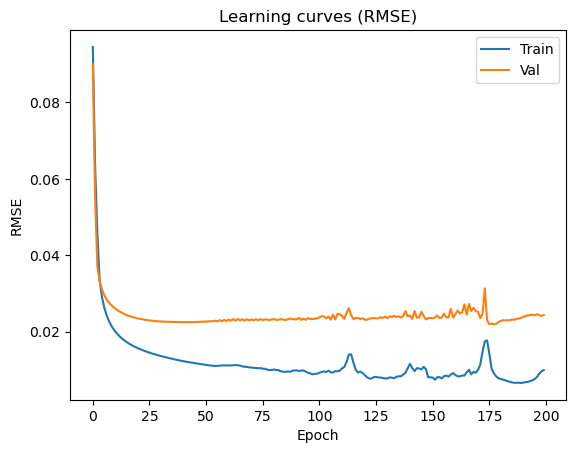

In [12]:
# Training
import math
#import os, math
best_val = math.inf
EPOCHS = 200
file_save_best_model = "best_mlp.pt"

def run_epoch(loader, train=False):
    if train: model.train()
    else: model.eval()
    losses = []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb)
        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        losses.append(loss.item())
    return np.mean(losses)

# YOUR CODE HERE
train_hist, val_hist = [], []
for epoch in range(1, EPOCHS+1):
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader, train=False)
    train_hist.append(tr); val_hist.append(va)
    val_rmse = np.sqrt(va)
    if val_rmse < best_val - 1e-6:
        best_val = val_rmse
        torch.save(model.state_dict(), file_save_best_model)
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Train MSE={tr:.6f} | Val RMSE={val_rmse:.6f}")

plt.figure()
plt.plot(np.sqrt(train_hist))
plt.plot(np.sqrt(val_hist))
plt.title("Learning curves (RMSE)")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend(["Train","Val"])
plt.show()

### 4.2 Test evaluation

Now the MLP is trained, the objective is to evaluate the performance on a non trained dataset: the test set.

<span style="color: blue;">**4.4** Compute the RMSE, MAE and Directional Accuracy of the **best** trained MLP on the test set.</span>

<span style="color: blue;">**4.5** Plot the predicted $\hat{y}_t$ and the real $y_t$ on the same graph.</span>


In [ ]:
# Load the best model (saved during learning)
model.load_state_dict(torch.load(file_save_best_model, map_location=device))
model.eval()

# Prediction on the test set
with torch.no_grad():
    y_test_pred = []
    for xb, _ in test_loader:
        xb = xb.to(device)
        y_test_pred.append(model(xb).cpu().numpy())
    y_test_pred = np.concatenate(y_test_pred, axis=0).squeeze()

# YOUR CODE HERE
# Use fct evaluate on y_test_pred and y_test to give the 3 metrics

# Plot y_test_pred and y_test on the same graph

## 5. Avoid / limit overfitting

The act of saving the best model (according to the validation set !) allows us to limit the overfitting effect. 

Another way to regularize the problem is to force several neurons to ouput zero. Specifically, the option "Dropout" of nn.Module allows us to easily fix a given rate of neuron (radomly chosen at each step) to outpu zero.

<span style="color: blue;">**5.1** Modify the MLP class to add, for each layer, the Dropout option with rate 0.2 (i.e. 20% of neurons outputting zero) and rerun the learning and performance evaluation.</span>



**Nota**: by saving the best model, we can add a control variable that allows to stop the run if overfitting is observed. For this, we can introduce a control variable `patience_cn` that counts the number of successive runs where the performance in the validation test is not increased. If `patience_cnt` is above a limit `patience_threshold` (patience_threshold = 30, i.e. no better performance during 30 steps), the run is stopped. 

<span style="color: blue;">**5.2** Redo the training with the new (regularized) MLP and the early stopping option explained above.</span>

<span style="color: blue;">**5.3** Compute the RMSE, MAE and Directional Accuracy of the **best** trained MLP on the test set.</span>

<span style="color: blue;">**5.4** Plot the predicted $\hat{y}_t$ and the real $y_t$ on the same graph.</span>

<span style="color: blue;">**5.5** What do you conclude ?</span>


In [ ]:
# Model: add nn.Dropout(alpha) step, with alpha = ratio of neurons desactivated
class MLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            # YOUR CODE HERE
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP(in_dim=X_train_s.shape[1]).to(device)

criterion = # YOUR CODE HERE
optimizer = # YOUR CODE HERE


# Training with early stopping on validation RMSE
# YOUR CODE HERE


## 6. Reflection / Improvements

** Questions**
- Did your NN beat the baselines significantly on RMSE or directional accuracy ?
- Why is forecasting noisy returns hard ?
- Is RMSE relevant for price prediction task ? Or any classical statistical loss ? 

** Improvements**
- Features of (short term, long term) tendency are often useful to improve prediction performance. For this, one can build moving averages of the most recent returns. For example :
- Moving Average (5 days): `df["ma_5"] = df["close"].rolling(5).mean()`
- Moving Aerage (20 days): `df["ma_20"] = df["close"].rolling(20).mean()`
- Exponentially Weighted Moving Average: `df["ema_10"] = df["close"].ewm(span=10, adjust=False).mean()`

The first two variables are averages of the last 5 (resp. 20) observed prices $$\text{ma}_N = \frac{1}{N}\sum_{k=0}^{N-1}P_{t-i}$$.

The last variable compute a classical exponentially weighted moving average, i.e creating the time series $$\text{ema}(t) = \alpha P_t + (1-\alpha)\text{ema}(t-1),$$ with $\alpha = \frac{2}{\text{span}+1}$. The parameter "span" corresponds to the average number of prices significantly taken into account in the averaging.

<span style="color: blue;">**6.1** Add these variables into $X$ and rerun the MLP training and evaluation.</span>

In [ ]:
df["ma_5"] = df["close"].rolling(5).mean() # Moving Average :
df["ma_20"] = df["close"].rolling(20).mean() # Moving Average
df["ema_10"] = df["close"].ewm(span=10, adjust=False).mean()
df[["close","ret","target","ma_5","ma_20","ema_10"]].head()


ma5  = df["ma_5"].to_numpy()
ma20 = df["ma_20"].to_numpy()
ema10 = df["ema_10"].to_numpy()

# Variables at time t (one value per window)
ma5_t  = ma5[K-1:]    # shape (N,)
ma20_t = ma20[K-1:]   # shape (N,)
ema10_t = ema10[K-1:] # shape (N,)

# Stack these three columns onto X along the column axis (axis=1)
X_new = np.concatenate(
    [X,
     ma5_t[:, None],
     ma20_t[:, None],
     ema10_t[:, None]
    ],
    axis=1
)

# Evaluate the performance of the new model
# YOUR CODE HERE

## A.1 The Long Short Term Memory (LSTM) model
In this appendix, the objective is to build a LSTM model and compare the results to the previous ones.

Because LSTM is based on time memory, we must build batches such that memory is kept. Here, we propose to start from scratch and not use the previous loaders. 

In [ ]:
# YOUR CODE HERE